<a href="https://colab.research.google.com/github/HamzaEric/Weather_LSTMs_GRUs/blob/main/Notebooks/Sequence_Length_Sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import random

In [2]:
CSV_PATH = "/content/drive/MyDrive/1_Daily_minimum_temps.csv"

df_raw = pd.read_csv(CSV_PATH, dtype={"Date": str})
assert "Date" in df_raw.columns and "Temp" in df_raw.columns, "Expected columns: Date, Temp"

def try_parse_date(series, fmt):
    dt = pd.to_datetime(series, format=fmt, errors="coerce")
    return dt, dt.notna().sum()


d1, ok1 = try_parse_date(df_raw["Date"], "%m/%d/%y")
d2, ok2 = try_parse_date(df_raw["Date"], "%d/%m/%y")

if ok1 >= ok2:
    df_raw["Date"] = d1
    chosen_fmt = "%m/%d/%y"
else:
    df_raw["Date"] = d2
    chosen_fmt = "%d/%m/%y"

print(f"Chosen date format: {chosen_fmt}  | parsed ok: {max(ok1, ok2)} / {len(df_raw)}")

# Drop unparsed rows (if any), cast Temp to float
df = df_raw.dropna(subset=["Date"]).copy()
df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")

# Set index, sort, keep only the signal
df = df.set_index("Date").sort_index()[["Temp"]]

# Basic sanity
assert df.index.is_monotonic_increasing, "Date index must be sorted ascending"
print("Shape:", df.shape)
print(df.head(3))
print(df.tail(3))


Chosen date format: %m/%d/%y  | parsed ok: 3650 / 3650
Shape: (3650, 1)
            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
            Temp
Date            
1990-12-29  13.5
1990-12-30  15.7
1990-12-31  13.0


In [3]:
s = df["Temp"].replace([np.inf, -np.inf], np.nan)
nan_before = s.isna().sum()

s = s.interpolate(method="linear", limit_direction="both")
nan_after = s.isna().sum()

df["Temp"] = s
print(f"Missing values before: {nan_before} | after interpolation: {nan_after}")

Missing values before: 3 | after interpolation: 0


In [4]:
train = df.loc["1981-01-01":"1987-12-31"].copy()
val   = df.loc["1988-01-01":"1988-12-31"].copy()
test  = df.loc["1989-01-01":"1990-12-31"].copy()

def span(x):
    return f"{x.index.min().date()} → {x.index.max().date()} ({len(x)} days)"

print("Train span:", span(train))
print("Val   span:", span(val))
print("Test  span:", span(test))

Train span: 1981-01-01 → 1987-12-31 (2555 days)
Val   span: 1988-01-01 → 1988-12-30 (365 days)
Test  span: 1989-01-01 → 1990-12-31 (730 days)


In [6]:
train_np = train[["Temp"]].to_numpy(dtype=float)
val_np   = val[["Temp"]].to_numpy(dtype=float)
test_np  = test[["Temp"]].to_numpy(dtype=float)

scaler = MinMaxScaler()
train_sc = scaler.fit_transform(train_np)
val_sc   = scaler.transform(val_np)
test_sc  = scaler.transform(test_np)

print("Scaled ranges:")
print("  Train:", float(train_sc.min()), "→", float(train_sc.max()))
print("  Val  :", float(val_sc.min()),   "→", float(val_sc.max()))
print("  Test :", float(test_sc.min()),  "→", float(test_sc.max()))

def make_single_step_windows(values: np.ndarray, S: int): # single step window means predict next step
    """
    values: (N,1) scaled series
    returns: X: (N-S, S, 1), y: (N-S, 1)
    """
    N = len(values)
    X = np.stack([values[i:i+S, :] for i in range(N - S)], axis=0)
    y = values[S:, :]  # next value after each window
    return X, y

# Default S for capacity tests; we’ll vary S later in Experiment A
S = 7

X_train_sc, y_train_sc = make_single_step_windows(train_sc, S)
X_val_sc,   y_val_sc   = make_single_step_windows(val_sc,   S)
X_test_sc,  y_test_sc  = make_single_step_windows(test_sc,  S)

print(f"Shapes @ S={S}:")
print("  X_train:", X_train_sc.shape, "| y_train:", y_train_sc.shape)
print("  X_val  :", X_val_sc.shape,   "| y_val  :", y_val_sc.shape)
print("  X_test :", X_test_sc.shape,  "| y_test :", y_test_sc.shape)

Scaled ranges:
  Train: 0.0 → 1.0
  Val  : 0.10646387832699619 → 0.9087452471482889
  Test : 0.019011406844106463 → 0.8403041825095058
Shapes @ S=7:
  X_train: (2548, 7, 1) | y_train: (2548, 1)
  X_val  : (358, 7, 1) | y_val  : (358, 1)
  X_test : (723, 7, 1) | y_test : (723, 1)


Batch X shape: (64, 7, 1) | Batch y shape: (64, 1)


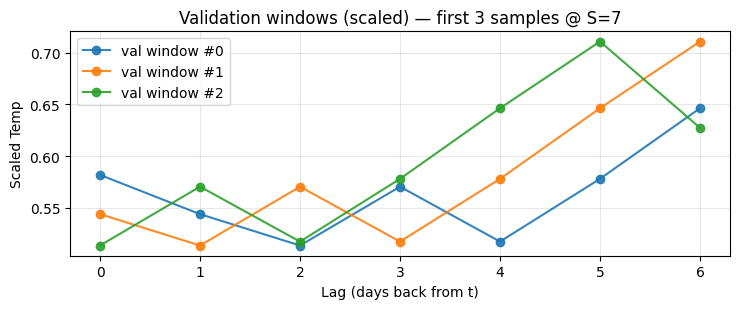

In [8]:
BATCH = 64

train_ds = TensorDataset(
    torch.tensor(X_train_sc, dtype=torch.float32),
    torch.tensor(y_train_sc, dtype=torch.float32),
)
val_ds = TensorDataset(
    torch.tensor(X_val_sc, dtype=torch.float32),
    torch.tensor(y_val_sc, dtype=torch.float32),
)
test_ds = TensorDataset(
    torch.tensor(X_test_sc, dtype=torch.float32),
    torch.tensor(y_test_sc, dtype=torch.float32),
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, drop_last=False)

# Batch-first confirmation
xb, yb = next(iter(train_loader))
print("Batch X shape:", tuple(xb.shape), "| Batch y shape:", tuple(yb.shape))  # expect (B, S, 1), (B, 1)

# Quick sanity plot: 3 validation windows (scaled)
plt.figure(figsize=(7.5, 3.2))
for i in range(3):
    w = X_val_sc[i, :, 0]  # length S
    plt.plot(range(S), w, marker="o", alpha=0.9, label=f"val window #{i}")
plt.title(f"Validation windows (scaled) — first {3} samples @ S={S}")
plt.xlabel("Lag (days back from t)")
plt.ylabel("Scaled Temp")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### **Experiment A — Sequence Length Sensitivity ($S\in\{7,14,30\}$)**

* Hypothesis: larger $S$ may encode **seasonal lead-ups** and reduce **phase lag**, but can also **raise variance** and slow learning.
* Keep **one cell type fixed** (e.g., **GRU**, 1 layer, hidden=64), vary **only $S$**.

**Code:**

* Loop over $S\in\{7,14,30\}$: rebuild windows/loaders; train **short** (e.g., 15–20 epochs).
* Track **train/val MSE** in scaled space, then compute **val MAE/RMSE** in °C.

**Outputs:**

* Table: $S$ vs val/test MAE & RMSE in °C.
* Plot: **val-loss vs epoch** per $S$ (overlay).

**Reflection:** Does larger $S$ flatten error at $k=1$? Any sign of **overfitting** (train ↓ while val ↔/↑)?


In [10]:
class GRUSingleStep(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=batch_first,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden_size, 1)  # linear head for regression in scaled space

    def forward(self, x):
        B = x.size(0)
        h0 = x.new_zeros(self.gru.num_layers, B, self.gru.hidden_size)
        out, _ = self.gru(x, h0)         # (B,S,H)
        h_last = out[:, -1, :]           # (B,H)
        y_hat  = self.head(h_last)       # (B,1) scaled
        return y_hat


In [11]:
DEVICE = torch.device("cpu")
EPOCHS = 18
LR     = 1e-3
CLIP   = 1.0
BATCH  = 64

criterion = nn.MSELoss()

def train_one_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, clip=CLIP):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    tr_hist, va_hist = [], []
    for ep in range(1, epochs+1):
        # Train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            yhat = model(xb)
            loss = criterion(yhat, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        # Eval (scaled MSE)
        tr_mse = eval_mse_scaled(model, train_loader)
        va_mse = eval_mse_scaled(model, val_loader)
        tr_hist.append(tr_mse); va_hist.append(va_mse)
        if ep in (1, 6, 12, epochs):
            print(f"[S={S_current}, ep {ep:02d}] train MSE={tr_mse:.5f} | val MSE={va_mse:.5f}")
    return tr_hist, va_hist

@torch.no_grad()
def eval_mse_scaled(model, loader):
    model.eval()
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        yhat = model(xb)
        loss = criterion(yhat, yb)
        bs = xb.size(0)
        tot += loss.item() * bs
        n   += bs
    return tot / max(n, 1)

@torch.no_grad()
def predict_scaled(model, X_sc, batch=BATCH):
    model.eval()
    preds = []
    for i in range(0, len(X_sc), batch):
        xb = torch.tensor(X_sc[i:i+batch], dtype=torch.float32).to(DEVICE)
        yhat = model(xb).cpu().numpy()
        preds.append(yhat)
    return np.vstack(preds)  # (N,1) scaled

def inverse_scale_1d(y_scaled):
    flat = y_scaled.reshape(-1, 1)
    back = scaler.inverse_transform(flat)
    return back.ravel()

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))


In [12]:
results = []
curves  = {}  # S -> (train_curve, val_curve)

S_values = [7, 14, 30]

for S_current in S_values:
    # Rebuild windows (scaled)
    X_train_sc_S, y_train_sc_S = make_single_step_windows(train_sc, S_current)
    X_val_sc_S,   y_val_sc_S   = make_single_step_windows(val_sc,   S_current)
    X_test_sc_S,  y_test_sc_S  = make_single_step_windows(test_sc,  S_current)

    # Build targets in °C to evaluate later
    _, y_val_C_S  = make_single_step_windows(val_np,  S_current)   # (N,1) in °C
    _, y_test_C_S = make_single_step_windows(test_np, S_current)

    # DataLoaders
    train_loader_S = DataLoader(
        TensorDataset(torch.tensor(X_train_sc_S, dtype=torch.float32),
                      torch.tensor(y_train_sc_S, dtype=torch.float32)),
        batch_size=BATCH, shuffle=True, drop_last=False)
    val_loader_S = DataLoader(
        TensorDataset(torch.tensor(X_val_sc_S, dtype=torch.float32),
                      torch.tensor(y_val_sc_S, dtype=torch.float32)),
        batch_size=BATCH, shuffle=False, drop_last=False)
    test_loader_S = DataLoader(
        TensorDataset(torch.tensor(X_test_sc_S, dtype=torch.float32),
                      torch.tensor(y_test_sc_S, dtype=torch.float32)),
        batch_size=BATCH, shuffle=False, drop_last=False)

    # Model
    model = GRUSingleStep(input_size=1, hidden_size=64, num_layers=1, batch_first=True, dropout=0.0)

    # Train briefly
    tr_curve, va_curve = train_one_model(model, train_loader_S, val_loader_S, epochs=EPOCHS, lr=LR, clip=CLIP)
    curves[S_current] = (tr_curve, va_curve)

    # Predict and report in °C (single-step)
    y_val_hat_sc  = predict_scaled(model, X_val_sc_S)[:, 0]   # (N,)
    y_test_hat_sc = predict_scaled(model, X_test_sc_S)[:, 0]
    y_val_hat_C   = inverse_scale_1d(y_val_hat_sc)
    y_test_hat_C  = inverse_scale_1d(y_test_hat_sc)

    # Flatten ground-truth (°C)
    y_val_true_C  = y_val_C_S.ravel()
    y_test_true_C = y_test_C_S.ravel()

    row = {
        "S": S_current,
        "Val_MAE_C":  mae(y_val_true_C,  y_val_hat_C),
        "Val_RMSE_C": rmse(y_val_true_C, y_val_hat_C),
        "Test_MAE_C":  mae(y_test_true_C,  y_test_hat_C),
        "Test_RMSE_C": rmse(y_test_true_C, y_test_hat_C),
    }
    results.append(row)

df_S = pd.DataFrame(results).set_index("S").sort_values("Val_RMSE_C")
display(df_S.round(3))


[S=7, ep 01] train MSE=0.01942 | val MSE=0.01861
[S=7, ep 06] train MSE=0.01079 | val MSE=0.00998
[S=7, ep 12] train MSE=0.00989 | val MSE=0.00952
[S=7, ep 18] train MSE=0.00944 | val MSE=0.00920
[S=14, ep 01] train MSE=0.01932 | val MSE=0.01803
[S=14, ep 06] train MSE=0.01006 | val MSE=0.00940
[S=14, ep 12] train MSE=0.00928 | val MSE=0.00878
[S=14, ep 18] train MSE=0.00903 | val MSE=0.00866
[S=30, ep 01] train MSE=0.01953 | val MSE=0.01729
[S=30, ep 06] train MSE=0.00971 | val MSE=0.00897
[S=30, ep 12] train MSE=0.00917 | val MSE=0.00865
[S=30, ep 18] train MSE=0.00893 | val MSE=0.00862


,Val_MAE_C,Val_RMSE_C,Test_MAE_C,Test_RMSE_C
S,,,,
30,1.892,2.441,1.754,2.245
14,1.897,2.447,1.769,2.248
7,1.994,2.523,1.824,2.316


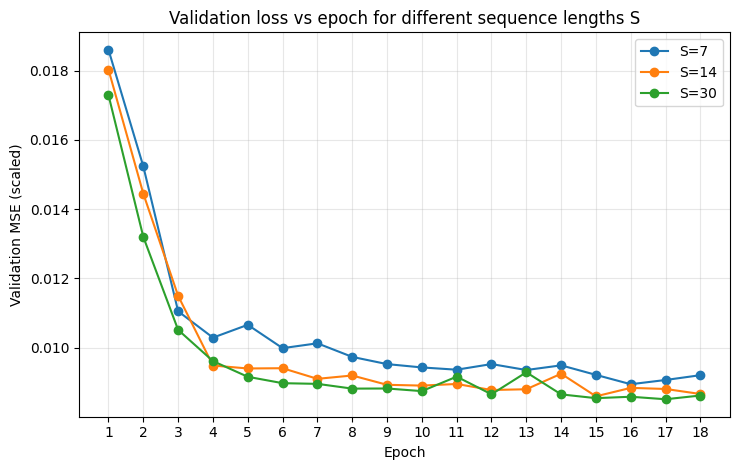

In [13]:
plt.figure(figsize=(7.5, 4.8))
for S_current in S_values:
    tr, va = curves[S_current]
    plt.plot(range(1, len(va)+1), va, marker="o", label=f"S={S_current}")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE (scaled)")
plt.title("Validation loss vs epoch for different sequence lengths S")
plt.xticks(range(1, EPOCHS+1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Best S by Val_RMSE_C: 30
[S=30, ep 01] train MSE=0.01994 | val MSE=0.01833
[S=30, ep 06] train MSE=0.00989 | val MSE=0.00911
[S=30, ep 08] train MSE=0.01022 | val MSE=0.00949


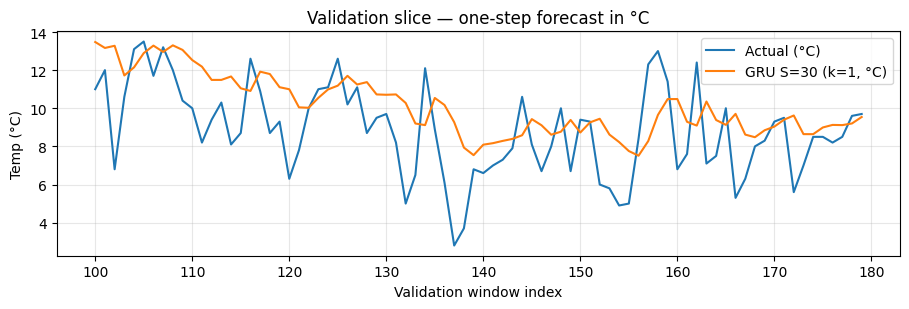

In [14]:
best_S = df_S.index[0]
print(f"Best S by Val_RMSE_C: {best_S}")

# Rebuild to get predictions for the chosen S (in case variables were overwritten)
X_val_sc_S, _ = make_single_step_windows(val_sc, best_S)
_, y_val_C_S  = make_single_step_windows(val_np, best_S)

# Refit a fresh model quickly for the slice (or reuse the trained one if kept)
model_bestS = GRUSingleStep(input_size=1, hidden_size=64, num_layers=1, batch_first=True, dropout=0.0)
# A quick re-train for 8 epochs to ensure the object is live (keeps CPU light)
_ , _ = train_one_model(model_bestS,
                        DataLoader(TensorDataset(torch.tensor(make_single_step_windows(train_sc, best_S)[0], dtype=torch.float32),
                                                 torch.tensor(make_single_step_windows(train_sc, best_S)[1], dtype=torch.float32)),
                                   batch_size=BATCH, shuffle=True),
                        DataLoader(TensorDataset(torch.tensor(X_val_sc_S, dtype=torch.float32),
                                                 torch.tensor(make_single_step_windows(val_sc, best_S)[1], dtype=torch.float32)),
                                   batch_size=BATCH, shuffle=False),
                        epochs=8)

y_val_hat_sc = predict_scaled(model_bestS, X_val_sc_S)[:, 0]
y_val_hat_C  = inverse_scale_1d(y_val_hat_sc)
y_val_true_C = y_val_C_S.ravel()

idx0, idx1 = 100, 180
x_axis = np.arange(idx0, idx1)
plt.figure(figsize=(9.2, 3.2))
plt.plot(x_axis, y_val_true_C[idx0:idx1], label="Actual (°C)")
plt.plot(x_axis, y_val_hat_C[idx0:idx1],  label=f"GRU S={best_S} (k=1, °C)")
plt.title("Validation slice — one-step forecast in °C")
plt.xlabel("Validation window index")
plt.ylabel("Temp (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
